In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import ipdb
import datetime as dt
import linecache as lc

from multiprocessing import Pool, Process, cpu_count
import tqdm
import time

In [2]:
path = '../Omni_data/HRO/'
names = ['Year','Doy','Hour','Minute','IMFz','Vz','AE','SYM']

years = range(2005,2015,5)

rang = [[],
       []]

print(years)
data_HRO = list(range(len(years)))

for i in range(len(years)):
    filename = path+str(years[i])+'.lst'
    data_HRO[i] = pd.read_csv(filename,
                       #header=None,
                       delimiter=r"\s+", 
                       #skiprows=[0,1],
                       engine = "python",
                       names=names,
                       #usecols=fileds,
                      )
data_HRO = pd.concat(data_HRO).values
idx = np.where((data_HRO[:,4]<=40) \
              &(data_HRO[:,4]>=-40) \
              &(data_HRO[:,5]>=-100) \
              &(data_HRO[:,5]<=100) \
              &(data_HRO[:,6]<=1500) \
              &(data_HRO[:,7]>=-200))[0]

data_HRO = data_HRO[idx,:]

def init():
    global data_HRO
    
def create_date(i):
    
    out = dt.datetime(int(data_HRO[i,0]),1,1,int(data_HRO[i,2]),int(data_HRO[i,3]))\
            + dt.timedelta(int(data_HRO[i,1])-1)
    return out

iteration = range(data_HRO.shape[0])
cores = cpu_count()
p = Pool(cores,init,())
date_HRO = []
year_HRO = []
month_HRO = []
dom_HRO = []
hour_HRO = []
minute_HRO = []

for t in tqdm.tqdm(p.imap_unordered(create_date, iteration) \
                   , total=len(iteration)):
    date_HRO.append(t)
    year_HRO.append(t.year)
    month_HRO.append(t.month)
    dom_HRO.append(t.day)
    hour_HRO.append(t.hour)
    minute_HRO.append(t.minute)

year_HRO = np.array(year_HRO)
month_HRO = np.array(month_HRO)
dom_HRO = np.array(dom_HRO)
hour_HRO = np.array(hour_HRO)
minute_HRO = np.array(minute_HRO)
print(len(date_HRO))

range(2005, 2015, 5)


100%|██████████| 945835/945835 [00:16<00:00, 58096.63it/s]


945835


In [3]:
string = lc.getlines("cosmic_list.txt")
print(string[0])
len(string)

/export/scratch2/andong/Data/ROdata/cosmic2013/ionPrf/2010.182/ionPrf_C003.2010.182.17.13.G20_2013.3520.nc



3378981

In [4]:
## CPU multiprocessing

#from multiprocessing import Pool, cpu_count
#from functools import partial

from scipy import io as sio
from multiprocessing import cpu_count, Pool
from random import sample
import tqdm
import ipdb
import netCDF4 as nc
import aacgmv2
from apexpy import Apex
# global value
def init():
    global string
    global date_HRO
    global year_HRO
    global month_HRO
    global dom_HRO
    global hour_HRO
    global minute_HRO
    global data
    

def readRO(ind,delay_minutes=0):
    
    
    #start = time.clock()
    path = string[ind]
    path = path.strip('\n')
    file = nc.Dataset(path)
    #print(file.variables.keys())
    #print(file.ncattrs)
    #for attr in file.ncattrs():
    #    print(attr)
    #ipdb.set_trace()
    VTEC0 = file.getncattr('tec0') 
    VTEC1 = file.getncattr('tec1')
    #VTEC = VTEC0 + VTEC1
    year = file.getncattr('year')
    month = file.getncattr('month')
    day = file.getncattr('day')
    hour = file.getncattr('hour')
    minute = file.getncattr('minute')
    
    doy = dt.datetime(year,month,day).timetuple().tm_yday
    UT = hour + minute/60
    
    min_five = np.round(minute/5)*5
    if min_five == 60:
        min_five = 0
    
    Lat_F2 = file.getncattr('edmaxlat')
    Lon_F2 = file.getncattr('edmaxlon')
    Alt_F2 = file.getncattr('edmaxalt')  
    NmF2 = file.getncattr('edmax')
    magm = np.zeros(3)
    X_HRO = np.zeros(4)

    RO_time = dt.datetime(int(year),int(month),
                          int(day),int(hour),int(min_five))
    
    
    delay_date = RO_time+dt.timedelta(minutes=delay_minutes)
    delay_year = delay_date.year
    delay_month = delay_date.month
    delay_dom = delay_date.day
    delay_hour = delay_date.hour
    delay_minute = delay_date.minute
    
    index_HRO = np.where((delay_year == year_HRO) &
                        (delay_month == month_HRO) &
                        (delay_dom == dom_HRO) &
                        (delay_hour == hour_HRO) &
                        (delay_minute == minute_HRO)
                        )[0]
    #ipdb.set_trace()
    if len(index_HRO) == 0:
        X_HRO = np.array([-99999,0,0,0])
    else:
        X_HRO = data_HRO[index_HRO[0],4:9]

    #ipdb.set_trace()
    
    '''
    if np.abs(Lat_F2)<0:
       
        # output: mLat,mLon,mlt
        magm = np.array(aacgmv2.get_aacgm_coord(\
                        Lat_F2,Lon_F2,Alt_F2, RO_time)) 
    else:
        A = Apex(date=RO_time)
        mlat, mlon = A.convert(Lat_F2,Lon_F2,'geo','apex',height=Alt_F2)
        mlt = A.mlon2mlt(Lon_F2,
                        RO_time)
        magm = np.vstack([mlat,mlon,mlt])
    '''
    
    #out = np.hstack([Alt_F2,magm.squeeze(),VTEC0,X_HRO.squeeze(),doy,VTEC1, NmF2, year])
    #ipdb.set_trace()
    
    out = np.hstack([Alt_F2,Lat_F2,Lon_F2,UT,VTEC0,X_HRO.squeeze(),doy,VTEC1, NmF2, year])
    file.close()
    

    return out
    
def Read_RO_delay(delay):
    
    out = []
    #iter = range(330000)
    for i in range(330000):
        start = time.time()
        
        out_temp = readRO(i,delay)
        #print(i)
        #ipdb.set_trace()
        if ((out_temp[4]>0) \
            & (out_temp[4]<50) \
            & (~np.isnan(out_temp[1])) \
            & (out_temp[1] != 0) \
            & (out_temp[5] != -99999)):
            
            #inputs_t = out_temp[0]
            out.append(out_temp)
            
        
        end = time.time()
        print(i, 'th, running time: ', end-start)
    
    sio.savemat('data/Delay/HRO_3.3w_'+str(delay)+'minutes.mat',{'out':out})

if __name__ == '__main__':

    iteration = range(-60,60,15)
    out = []
    #print(iteration)
    cores = cpu_count()
    print(cores)
    
    
    p = Pool(cores,init,())
    start = time.time()
    
    
    iter = range(0,3300000)
    for t in tqdm.tqdm(p.imap_unordered(readRO, iter) \
                       , total=len(iter)):
        #pass
        out.append(t)
    
    sio.savemat('data/Delay/330w_0_minutes_geog.mat',{'out':out})    
    '''
    for t in tqdm.tqdm(p.imap_unordered(Read_RO_delay, iteration) \
                       , total=len(iteration)):
        pass
        #out.append(t)
    '''
    '''
    for i in range(100):
        
        out.append(readRO(i))
    '''
    
    end = time.time()
    print('running time: ', end-start)

    #sio.savemat('data/RO_output_'+YMD_test+'.mat',{'out':out})

8


100%|██████████| 3300000/3300000 [1:12:44<00:00, 756.03it/s] 


running time:  4366.556548118591


In [18]:
from scipy import io as sio
from pyitlib import discrete_random_variable as drv
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

%matplotlib notebook

vari_set = ['IMFz','Vz','AE','SYM']
iteration = range(-60,60,15)
MI = np.zeros([len(iteration), len(vari_set)])
MI_mean = np.zeros([len(iteration), len(vari_set)])
MI_std = np.zeros([len(iteration), len(vari_set)])
CMI = np.zeros([len(iteration), len(vari_set)])
CMI_mean = np.zeros([len(iteration), len(vari_set)])
CMI_std = np.zeros([len(iteration), len(vari_set)])

for i in iteration:
    data = sio.loadmat('data/Delay/HRO_3.3w_'+str(i)+'minutes.mat') 
   
    ALT = data['out'][:,0]
    mLat = data['out'][:,1]
    mLon = data['out'][:,2]
    mLT = data['out'][:,3]
    VTEC0 = data['out'][:,4]
    
    varis = data['out'][:,5:9]
    DoY = data['out'][:,9]
    VTEC1 = data['out'][:,10]
    NmF2 = data['out'][:,11]

    '''
    
    fig1 = plt.figure(0, figsize=(9,9))

    for i in range(len(vari_set)):

        plt.subplot(331+i)
        plt.hist(varis[:,i])
        plt.subplots_adjust(wspace =0.5, hspace =1)
        plt.xlabel('Values')
        plt.ylabel('Number')
        
    plt.show()
    '''
    #ipdb.set_trace()
    #print(i)
    ind = np.where(np.abs((mLat)>60) \
                   #& (mLat<-58+5)\
                   #& (mLon>20-10)\
                   #& (mLon<20+10)\
                   & (~np.isnan(varis[:,0])) \
                   & (~np.isnan(varis[:,1])) \
                   & (~np.isnan(varis[:,2])) \
                   & (~np.isnan(varis[:,3])) \
                   #& (varis[:,3]<-30) \
                   & (VTEC1 > 0)\
                  )[0]
    sample_num = int(len(ind)*0.7)
    
    #ipdb.set_trace()

    #varis = varis[ind]/LA.norm(varis[ind])
    #VTEC0 = LA.norm(VTEC0[ind])
    
    varis = varis[ind,:]
    
    #ipdb.set_trace()
    varis = varis[:,:] - varis[:,:].min(axis=0)
    varis = varis/(varis[:,:].max(axis=0) - varis[:,:].min(axis=0))
    varis =np.round(varis*100)
    
    #print(varis)
    
    VTEC0 = VTEC0[ind]
    VTEC1 = VTEC1[ind]
    #NmF2 = np.log(NmF2[ind])
    NmF2 = NmF2[ind]
    #ipdb.set_trace()
    NmF2 = NmF2[:] - NmF2[:].min(axis=0)
    NmF2 = NmF2/(NmF2[:].max(axis=0) - NmF2[:].min(axis=0))
    NmF2 =np.round(NmF2*100)
    
    #ipdb.
    for j in range(varis.shape[1]):
        print('j=',j)
        num_resample = 50
        MI_t = np.zeros(num_resample)
        CMI_t = np.zeros(num_resample)
        
        MI[np.int((i+60)/15),j]=normalized_mutual_info_score(
            varis[0:sample_num,j],NmF2[0:sample_num])
                
        CMI[np.int((i+60)/15),j]=drv.information_mutual_conditional(
            varis[0:sample_num,j],NmF2[0:sample_num],\
            varis[0:sample_num,3])

        for k in range(num_resample):

            ind_t = np.array(range(ind.shape[0]))
            # shuffle the ind randomly 50 times, and each time with 60% data

            np.random.shuffle(ind_t)
            #ipdb.set_trace()
            ind_t = ind_t[0:sample_num]
            MI_t[k] = normalized_mutual_info_score(
                varis[ind_t,j],NmF2[ind_t]) - MI[np.int((i+60)/15),j]
            CMI_t[k] = drv.information_mutual_conditional(
                varis[ind_t,j],NmF2[ind_t],\
                varis[ind_t,0]) - CMI[np.int((i+60)/15),j]
        #ipdb.set_trace()

        MI_mean[np.int((i+60)/15),j] = MI_t.mean()
        CMI_mean[np.int((i+60)/15),j] = CMI_t.mean()
        MI_std[np.int((i+60)/15),j] = MI_t.std()
        CMI_std[np.int((i+60)/15),j] = CMI_t.std()
        #ipdb.set_trace()

        MI[np.int((i+60)/15),j]=normalized_mutual_info_score(
            varis[0:sample_num,j],NmF2[0:sample_num])
                
        CMI[np.int((i+60)/15),j]=drv.information_mutual_conditional(
            varis[0:sample_num,j],NmF2[0:sample_num],\
            varis[0:sample_num,3])




j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3
j= 0
j= 1
j= 2
j= 3


<IPython.core.display.Javascript object>


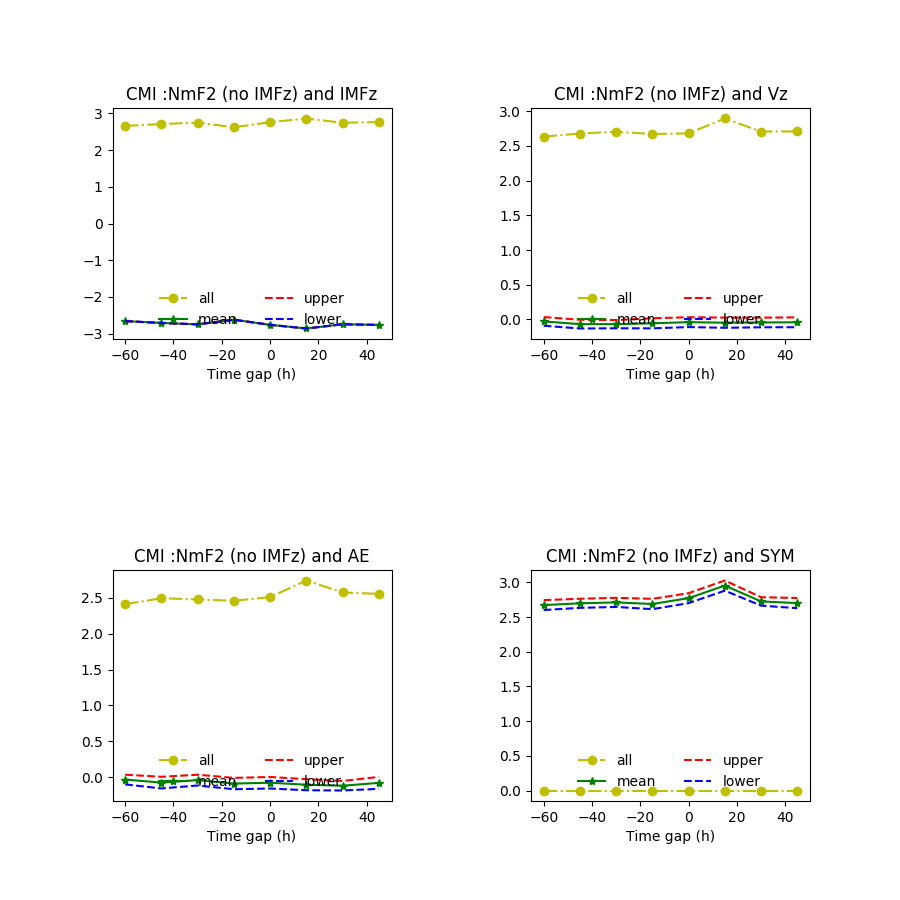

<IPython.core.display.Javascript object>


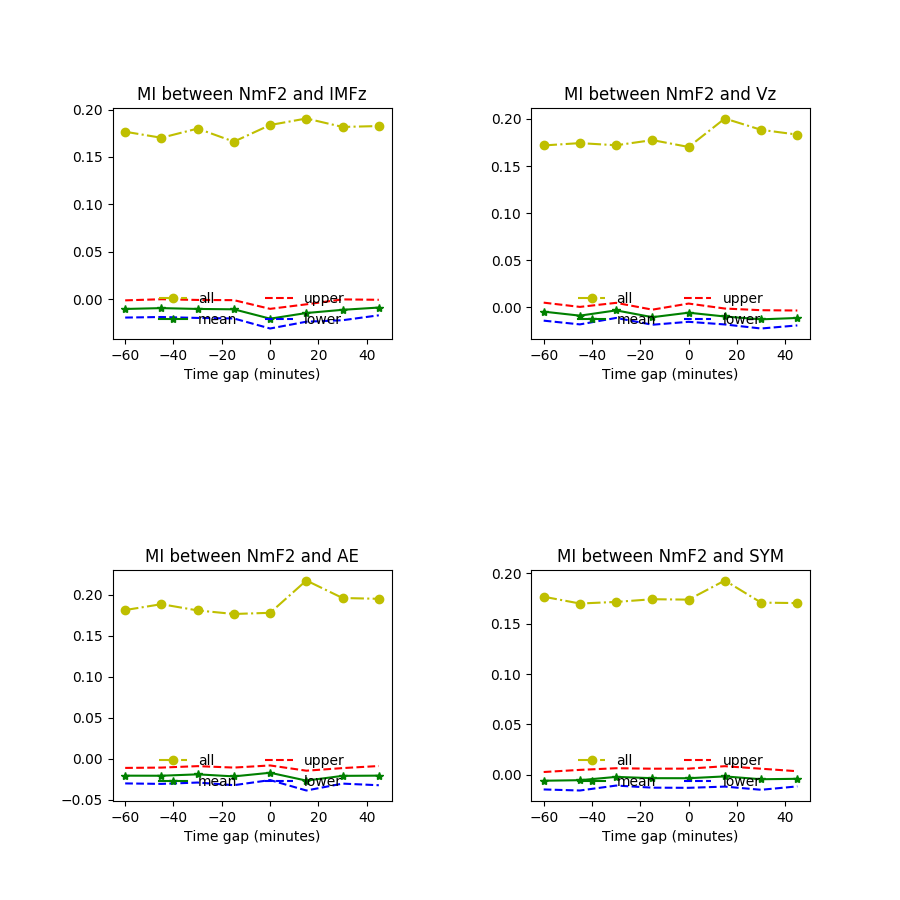

In [23]:

fig1 = plt.subplots(2,2, figsize=(9,9))

for i in range(len(vari_set)):

    plt.subplot(221+i)
    plt.plot(iteration,CMI[:,i],'yo-.',label='all')
    plt.plot(iteration,CMI_mean[:,i],'g*-',label='mean')
    plt.plot(iteration,CMI_mean[:,i]+3*CMI_std[:,i],'r--',label='upper')
    plt.plot(iteration,CMI_mean[:,i]-3*CMI_std[:,i],'b--',label='lower')
    plt.subplots_adjust(wspace =0.5, hspace =1)
    plt.xlabel('Time gap (h)')
    plt.legend(frameon=False, loc='lower center',ncol=2)
    plt.title('CMI :NmF2 (no '+vari_set[0]+') and '+vari_set[i])

plt.show()
titlefig = 'CMI_test_NmF2'+vari_set[0]+'_highhlat.png'
#fig1.savefig(titlefig, dpi=300)
#plt.close()

fig2 = plt.subplots(2,2, figsize=(9,9))

for i in range(len(vari_set)):

    plt.subplot(221+i)
    plt.plot(iteration,MI[:,i],'yo-.',label='all')
    plt.plot(iteration,MI_mean[:,i],'g*-',label='mean')
    plt.plot(iteration,MI_mean[:,i]+3*MI_std[:,i],'r--',label='upper')
    plt.plot(iteration,MI_mean[:,i]-3*MI_std[:,i],'b--',label='lower')
    plt.subplots_adjust(wspace =0.5, hspace =1)
    plt.xlabel('Time gap (minutes)')
    plt.legend(frameon=False, loc='lower center',ncol=2)
    plt.title('MI between NmF2 and '+vari_set[i])

plt.show()
titlefig = 'MI_test_NmF2_highlat.png'
#fig2.savefig(titlefig, dpi=300)

